In [20]:
from ISLP import load_data
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm
from pygam import LinearGAM, s, f
import operator 
from functools import reduce
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
data = load_data("College")
data.head()

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


The main problem is to find out what predictor (or multiple predictors) have influence on students tuition fee who are based out of state or
are international students from abroad.

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 777 entries, 0 to 776
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   Private      777 non-null    category
 1   Apps         777 non-null    int64   
 2   Accept       777 non-null    int64   
 3   Enroll       777 non-null    int64   
 4   Top10perc    777 non-null    int64   
 5   Top25perc    777 non-null    int64   
 6   F.Undergrad  777 non-null    int64   
 7   P.Undergrad  777 non-null    int64   
 8   Outstate     777 non-null    int64   
 9   Room.Board   777 non-null    int64   
 10  Books        777 non-null    int64   
 11  Personal     777 non-null    int64   
 12  PhD          777 non-null    int64   
 13  Terminal     777 non-null    int64   
 14  S.F.Ratio    777 non-null    float64 
 15  perc.alumni  777 non-null    int64   
 16  Expend       777 non-null    int64   
 17  Grad.Rate    777 non-null    int64   
dtypes: category(1), float64(1), in

In [4]:
data.shape

(777, 18)

In [5]:
data.describe()

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
count,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.00000
mean,3001.638353,2018.804376,779.972973,27.558559,55.796654,3699.907336,855.298584,10440.669241,4357.526384,549.380952,1340.642214,72.660232,79.702703,14.089704,22.743887,9660.171171,65.46332
std,3870.201484,2451.113971,929.176190,17.640364,19.804778,4850.420531,1522.431887,4023.016484,1096.696416,165.105360,677.071454,16.328155,14.722359,3.958349,12.391801,5221.768440,17.17771
min,81.000000,72.000000,35.000000,1.000000,9.000000,139.000000,1.000000,2340.000000,1780.000000,96.000000,250.000000,8.000000,24.000000,2.500000,0.000000,3186.000000,10.00000
25%,776.000000,604.000000,242.000000,15.000000,41.000000,992.000000,95.000000,7320.000000,3597.000000,470.000000,850.000000,62.000000,71.000000,11.500000,13.000000,6751.000000,53.00000
50%,1558.000000,1110.000000,434.000000,23.000000,54.000000,1707.000000,353.000000,9990.000000,4200.000000,500.000000,1200.000000,75.000000,82.000000,13.600000,21.000000,8377.000000,65.00000
75%,3624.000000,2424.000000,902.000000,35.000000,69.000000,4005.000000,967.000000,12925.000000,5050.000000,600.000000,1700.000000,85.000000,92.000000,16.500000,31.000000,10830.000000,78.00000
max,48094.000000,26330.000000,6392.000000,96.000000,100.000000,31643.000000,21836.000000,21700.000000,8124.000000,2340.000000,6800.000000,103.000000,100.000000,39.800000,64.000000,56233.000000,118.00000


In [19]:
data.head()

AttributeError: 'list' object has no attribute 'head'

<Axes: >

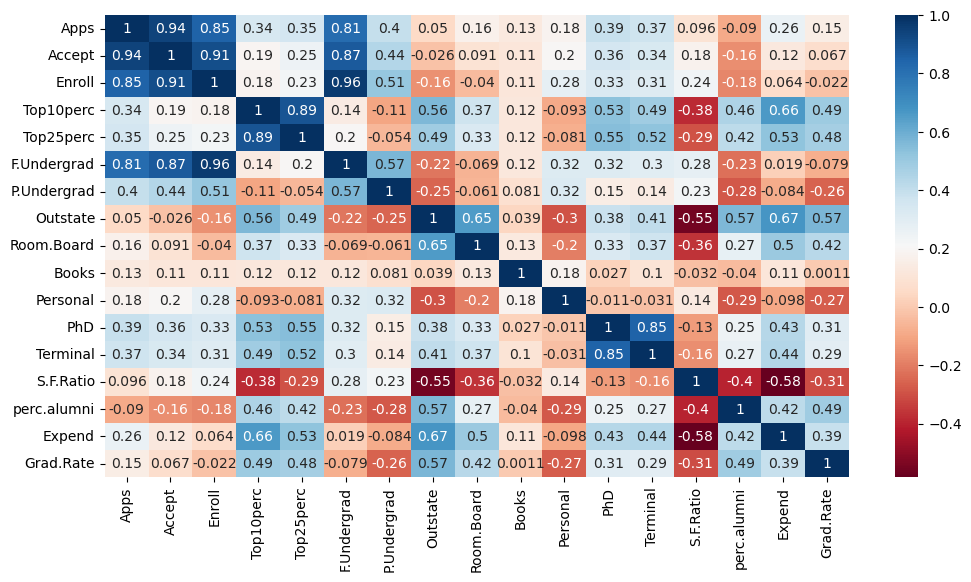

In [6]:
plt.figure(figsize=(12,6))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap="RdBu")

This map is too big and I don't see much on it. I will do the mask and make threshold instead. By that I will print out cols that have correlation > 0.7 with at least 1 column

<Axes: >

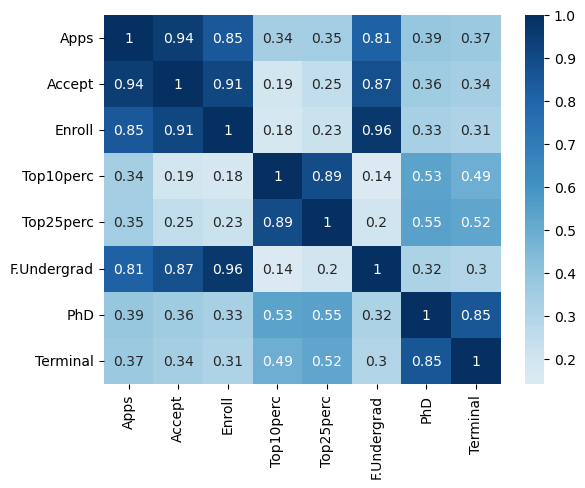

In [7]:
corr = data.corr(numeric_only=True)
threshold = 0.7

cols = corr.columns[
    (corr.abs() >= threshold).sum(axis=1) > 1
]

corr_filtered = corr.loc[cols, cols]


sns.heatmap(
    corr_filtered,
    annot=True,
    cmap="RdBu",
    center=0
)



### There is big chance for linear correlation in this dataset.

In [8]:
y = data["Outstate"]
X = data.drop(columns=["Outstate", "Private"])
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 156 entries, 568 to 292
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Apps         156 non-null    int64  
 1   Accept       156 non-null    int64  
 2   Enroll       156 non-null    int64  
 3   Top10perc    156 non-null    int64  
 4   Top25perc    156 non-null    int64  
 5   F.Undergrad  156 non-null    int64  
 6   P.Undergrad  156 non-null    int64  
 7   Room.Board   156 non-null    int64  
 8   Books        156 non-null    int64  
 9   Personal     156 non-null    int64  
 10  PhD          156 non-null    int64  
 11  Terminal     156 non-null    int64  
 12  S.F.Ratio    156 non-null    float64
 13  perc.alumni  156 non-null    int64  
 14  Expend       156 non-null    int64  
 15  Grad.Rate    156 non-null    int64  
dtypes: float64(1), int64(15)
memory usage: 20.7 KB


In [26]:
vals = [variance_inflation_factor(X_train, i ) for i in range (X_train.shape[1])]

vif = pd.DataFrame({
    "vif": vals
},
    index=X_train.columns[:])
vif


,vif
Apps,22.301542
Accept,36.233186
Enroll,35.242629
Top10perc,23.648365
Top25perc,47.480230
F.Undergrad,25.739578
P.Undergrad,2.607320
Room.Board,25.760211
Books,12.923892
Personal,5.991853


In [9]:
remaining_cols = list(X_train.columns)
selected = []
current_aic = float("inf")
# AIC - balance between fitting and complexity

while remaining_cols:
    aic_candidates = []

    for candidate in remaining_cols:
        X_model = sm.add_constant(X_train[selected + [candidate]])
        model = sm.OLS(Y_train, X_model).fit()
        aic_candidates.append((model.aic, candidate))

    best_aic, best_candidate = min(aic_candidates)

    if best_aic < current_aic:
        remaining_cols.remove(best_candidate)
        selected.append(best_candidate)
        current_aic = best_aic
    else:
        break

print("Chosen variables:", selected)


Chosen variables: ['Expend', 'Room.Board', 'perc.alumni', 'Grad.Rate', 'F.Undergrad', 'Terminal', 'S.F.Ratio', 'Accept', 'Apps', 'Top10perc']


In [10]:
X_final = sm.add_constant(X_train[selected])
model = sm.OLS(Y_train, X_final).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               Outstate   R-squared:                       0.731
Model:                            OLS   Adj. R-squared:                  0.726
Method:                 Least Squares   F-statistic:                     165.6
Date:                Tue, 16 Dec 2025   Prob (F-statistic):          1.65e-166
Time:                        11:40:30   Log-Likelihood:                -5626.6
No. Observations:                 621   AIC:                         1.128e+04
Df Residuals:                     610   BIC:                         1.132e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        -277.2980    765.991     -0.362      

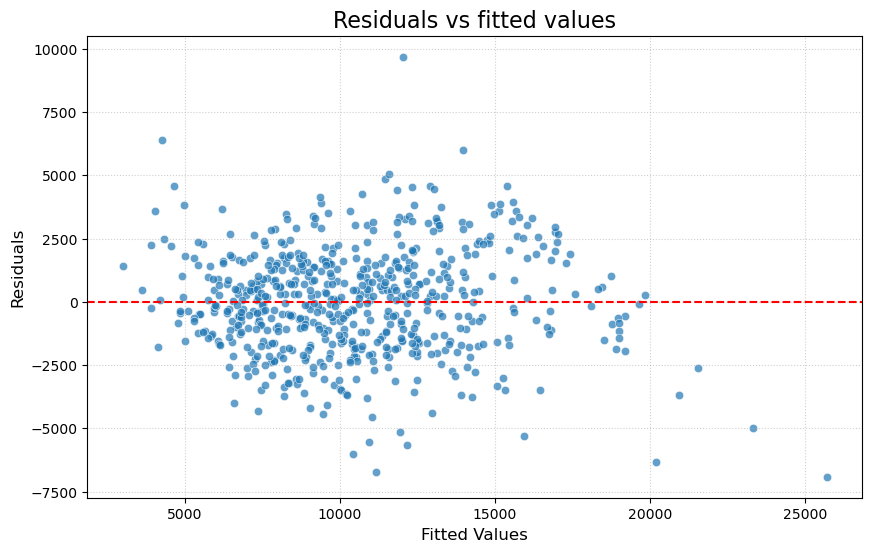

In [11]:
residuals = model.resid
fitted_values = model.fittedvalues

plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted_values, y=residuals, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs fitted values', fontsize=16)
plt.xlabel('Fitted Values', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

### There is no clear sign for linear residuals. It looks very random (because of the different variance)

# Now i will fit a GAM model

In [12]:

s_indices = range(10)  
gam_terms = [s(i) for i in s_indices]
formula = reduce(operator.add, gam_terms)

# i want to avoid repetetive code:  LinearGAM(s(0) + s(1) + ...)

gam = LinearGAM(formula)
formula

s(0) + s(1) + s(2) + s(3) + s(4) + s(5) + s(6) + s(7) + s(8) + s(9)

In [27]:
gam.fit(X_train, Y_train)
y_pred_gam = gam.predict(X_test)
y_pred_gam2 = gam.predict(X_train)
SSE = np.sum((Y_test - y_pred_gam)**2)
SSE

np.float64(1098086637.3971615)

In [14]:
mean_squared_error(Y_test, y_pred_gam)

7039016.906392061

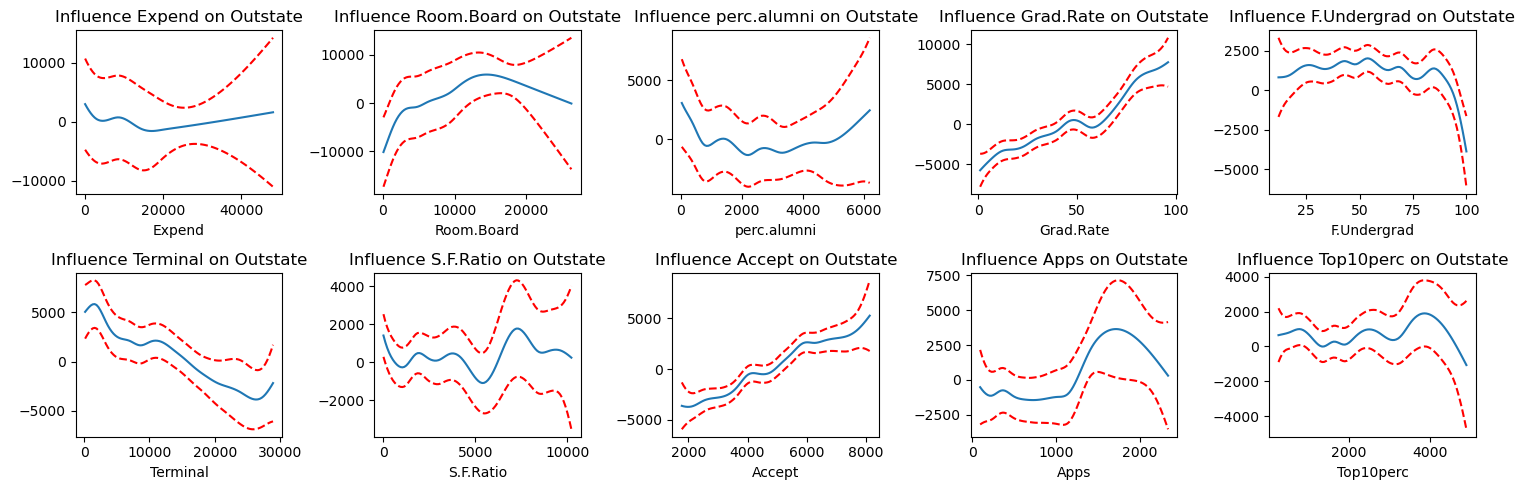

In [15]:
plt.figure(figsize=(15, 5))

for i, feature in enumerate(selected):
    XX = gam.generate_X_grid(term=i)
    
    # calc confidence interval 95%
    pdp, confi = gam.partial_dependence(term=i, X=XX, width=.95)
    
    ax = plt.subplot(2, 5, i + 1)
    
    ax.plot(XX[:, i], pdp)
    ax.plot(XX[:, i], confi, c='r', ls='--')
    ax.set_title(f'Influence {feature} on Outstate')
    ax.set_xlabel(feature)
    
plt.tight_layout()
plt.show()

In general predictors Expend, Grad.Rate, Terminal and Accept looks like linear correlation

It is important to note that GAM model is a sum of independent predictors.  

In [16]:
gam.summary()

LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     89.1394
Link Function:                     IdentityLink Log Likelihood:                                -10109.0056
Number of Samples:                          621 AIC:                                              20398.29
                                                AICc:                                           20429.2991
                                                GCV:                                          6283188.1583
                                                Scale:                                        4683955.0127
                                                Pseudo R-Squared:                                   0.7511
Feature Function                  Lam

C:\Users\Pytla\AppData\Local\Temp\ipykernel_25008\3358381670.py:1: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  gam.summary()


## Let's visualize better results

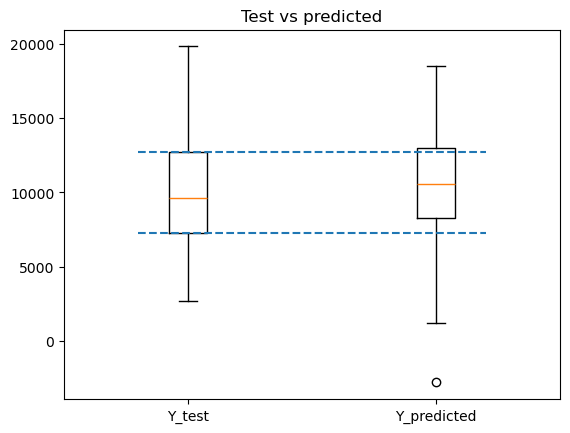

In [17]:
data = [Y_test, y_pred_gam]

fig, ax = plt.subplots()
ax.boxplot(data)
ax.set_title("Test vs predicted")
ax.set_xticks([1, 2])
ax.set_xticklabels(["Y_test", "Y_predicted"])


q1_ref = np.percentile(Y_test, 25)
q3_ref = np.percentile(Y_test, 75)

ax.hlines([q1_ref, q3_ref], 0.8, 2.2, linestyles="dashed")


                                 
plt.show()

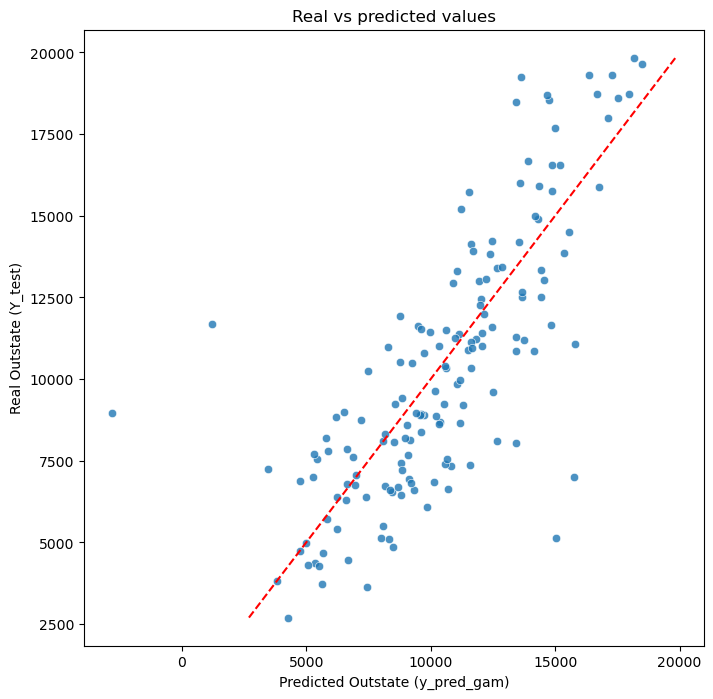

0.6566591361701675


In [29]:
plt.figure(figsize=(8, 8))
sns.scatterplot(x=y_pred_gam, y=Y_test, alpha=0.8)
plt.plot([min(Y_test), max(Y_test)], [min(Y_test), max(Y_test)], color='red', linestyle='--')
plt.title('Real vs predicted values')
plt.xlabel('Predicted Outstate (y_pred_gam)')
plt.ylabel('Real Outstate (Y_test)')
plt.show()

r2 = r2_score(y_pred_gam2, Y_train)
print(r2)

According to the graph I can see that model is inaccurate and majority values are underfitted and overfitted with big variance. Few outliers as well

# d)
Non linear relationship is in all predictor except: Grad. rate, Accept, Terminal.